# Rotor frequency noise and expected Pb-212 recoil

1. **Rotor frequency:** track the LES line, pick a stationary window, compute the frequency-noise PSD.
2. **Pb-212 recoil:** convert the expected recoil force into a rotor-frequency signal and compare it with
   the measured fluctuations.

**To run on another dataset, edit only the parameter cell (§0.1).** Method checks behind the choices made
here (raw bin vs interpolation, window lengths, Welch vs full-record, 30 s tracker) are in
`noise_budget_20260911.ipynb`.

## 0. Parameters and data

### 0.1 Parameters

In [1]:
import os, numpy as np, h5py
import matplotlib.pyplot as plt
from scipy.signal import decimate, periodogram

# ---------------- run-specific parameters: edit only this cell for another run ----------------
DATA     = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data')
LES_FILE = 'LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_1473204000_1473376497.h5'   # 09-11 -> 09-13 laser-driven hold
PD_FILE  = 'PD/Y1_RDS-PD_IN1_DQ_1473204000_1473376497.h5'             # laser pickoff PD, same stretch
WIN_H    = (1, 40)          # analysis window, hours from the first tracker estimate
BLOCK_H  = 2                # block length of the stationarity table (h)

F_LINE_GUESS = 1.50         # Hz, initial LES line frequency (= DIVISOR x rotor frequency)
DIVISOR  = 2                # rotor frequency = LES line / DIVISOR (two wings)
BAND     = (0.85, 1.10)     # search band, as fractions of the current line estimate
DECIM    = (8, 8)           # FIR decimation stages (1024 Hz -> 16 Hz)
WIN_BASE, STEP_BASE = 150.0, 60.0   # base tracker, s (self-tracking; guides the primary)
WIN_P,    STEP_P    = 60.0, 20.0    # primary tracker, s

I_TOTAL  = 1.1e-11          # kg m^2, from the weighed 7 mg assembly (±10%)
TAU_S    = 79.8*60          # s, mechanical spin-down time constant
R_EFF    = 1.38e-3          # m, lever arm (wing centroid)
R_TIP    = 1.88e-3          # m, wing tip (geometry comparison)
F0_PB    = 5.1e-15          # N, Pb-212 recoil force at t = 0 = start of WIN_H
T_HALF_H = 10.6             # h, Pb-212 half-life

### 0.2 Data

In [2]:
def load(path):
    """Segment-aware .h5 reader; checks for gaps."""
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        g0, i0, L = s['gps_start'][:], s['index_start'][:], s['length'][:]
        t = np.empty(len(y))
        for a, b, c in zip(g0, i0, L):
            t[b:b + c] = a + np.arange(c) / fs
    gap = np.abs(np.diff(g0) - L[:-1] / fs).max() if len(g0) > 1 else 0
    print(f'{os.path.basename(path)}: {len(y)/fs/3600:.2f} h, {len(g0)} segments, max gap {gap:.3f} s')
    return y, t, fs

def to_1hz(y, t, fs):
    n = int(len(y) // fs * fs); k = int(fs)
    return y[:n].reshape(-1, k).mean(1), t[:n].reshape(-1, k).mean(1)

les, t_les, fs = load(f'{DATA}/{LES_FILE}')
pd_raw, t_pd, fs_pd = load(f'{DATA}/{PD_FILE}')
pd1, tpd1 = to_1hz(pd_raw, t_pd, fs_pd); del pd_raw, t_pd      # PD at 1 Hz

Y1_RDS-LES_YAW_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s


## 1. Rotor frequency

### 1.1 Base frequency track

LES decimated to ~16 Hz. In each window: Hann window, FFT, largest peak in a band around the current
line estimate, three-point parabolic interpolation, ÷ `DIVISOR` → rotor frequency. The base tracker
(`WIN_BASE`/`STEP_BASE`) follows the line on its own, starting from `F_LINE_GUESS`. The laser PD is
averaged over the same windows and shown below it.

fs = 16 Hz; base tracker 150 s window, 60 s step, bin df_rotor = 3.33 mHz
2873 estimates, FR 0.4125..0.7889 Hz, median SNR 622


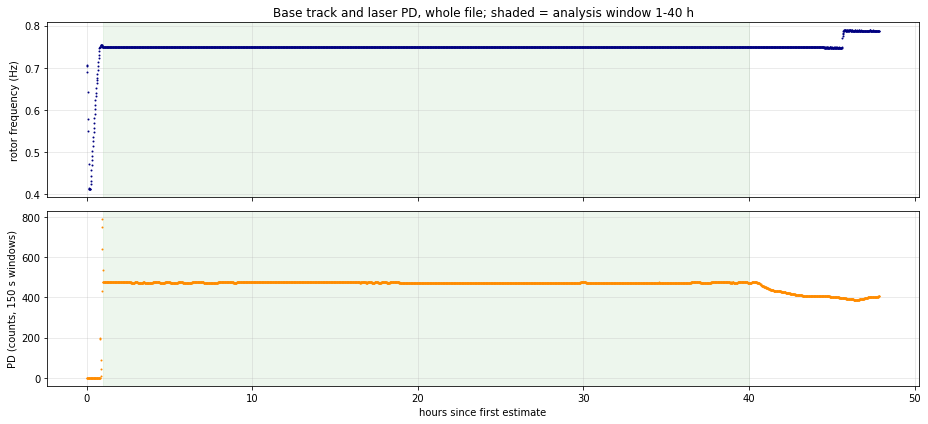

In [3]:
def peak_in_band(x, fsx, lo, hi):
    """Largest Hann-windowed FFT peak in (lo, hi). Returns (f_raw, f_interp, snr):
    f_raw is the peak bin's frequency fr[i]; f_interp adds the three-point parabolic correction."""
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fr[i], fpk, snr

def track_rotor(win, step, guide=None):
    """Track the LES line with win-s windows every step s. Returns (T, f_raw, f_interp, snr), rotor Hz.
    guide=None: the band follows this tracker's own last estimate, starting at F_LINE_GUESS.
    guide=(T_g, F_g): the band is centred on that track (rotor Hz) at each window centre."""
    nw_, sw_ = int(win*fs_d), int(step*fs_d)
    rows_, trk = [], F_LINE_GUESS
    for i in range(0, len(y_d)-nw_, sw_):
        tc = t_d[i] + win/2
        if guide is not None: trk = np.interp(tc, *guide)*DIVISOR
        fraw, fpk, snr = peak_in_band(y_d[i:i+nw_], fs_d, max(trk*BAND[0], 0.02), trk*BAND[1])
        if np.isnan(fpk) or fpk <= 0: continue
        rows_.append((tc, fraw/DIVISOR, fpk/DIVISOR, snr))
        trk = fpk
    return map(np.array, zip(*rows_))

y_d = les - les.mean()
for q in DECIM: y_d = decimate(y_d, q, ftype='fir')
fs_d = fs/np.prod(DECIM)
t_d = t_les[0] + np.arange(len(y_d))/fs_d
del les, t_les

T, _, FR, SNR = track_rotor(WIN_BASE, STEP_BASE)
T_REF = T[0]                                    # hours are counted from the first estimate
H_ALL = (T - T_REF)/3600
print(f'fs = {fs_d:g} Hz; base tracker {WIN_BASE:.0f} s window, {STEP_BASE:.0f} s step, '
      f'bin df_rotor = {fs_d/int(WIN_BASE*fs_d)/DIVISOR*1e3:.2f} mHz')
print(f'{len(T)} estimates, FR {FR.min():.4f}..{FR.max():.4f} Hz, median SNR {np.median(SNR):.0f}')

# PD averaged over exactly the base tracker's windows -> same time grid as FR
PDW = np.array([pd1[(tpd1 >= tc - WIN_BASE/2) & (tpd1 < tc + WIN_BASE/2)].mean() for tc in T])

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(H_ALL, FR, '.', ms=2, color='navy'); ax[0].set_ylabel('rotor frequency (Hz)')
ax[1].plot(H_ALL, PDW, '.', ms=2, color='darkorange'); ax[1].set_ylabel(f'PD (counts, {WIN_BASE:.0f} s windows)')
for a in ax:
    a.axvspan(*WIN_H, color='green', alpha=0.07); a.grid(alpha=.3)
ax[1].set_xlabel('hours since first estimate')
ax[0].set_title(f'Base track and laser PD, whole file; shaded = analysis window {WIN_H[0]}-{WIN_H[1]} h')
plt.tight_layout(); plt.show()

### 1.2 Analysis window

`WIN_H` should cover a stationary stretch of the operating point. Check it with the block table: mean
frequency and std per `BLOCK_H`-hour block, over the whole file.

In [4]:
mref = (H_ALL >= WIN_H[0]) & (H_ALL <= WIN_H[1])     # the analysis window, used throughout

print(f"{'hours':>7} | {'mean f (Hz)':>11} | {'std (mHz)':>9}")
for a in np.arange(WIN_H[0], H_ALL.max() - BLOCK_H/2, BLOCK_H):
    m = (H_ALL >= a) & (H_ALL < a + BLOCK_H)
    print(f'{a:3.0f}-{a+BLOCK_H:<3.0f} | {FR[m].mean():11.5f} | {FR[m].std()*1e3:9.3f}')

  hours | mean f (Hz) | std (mHz)
  1-3   |     0.74897 |     0.101
  3-5   |     0.74898 |     0.111
  5-7   |     0.74887 |     0.110
  7-9   |     0.74900 |     0.134
  9-11  |     0.74915 |     0.068
 11-13  |     0.74908 |     0.080
 13-15  |     0.74902 |     0.084
 15-17  |     0.74901 |     0.083
 17-19  |     0.74897 |     0.090
 19-21  |     0.74903 |     0.113
 21-23  |     0.74914 |     0.092
 23-25  |     0.74910 |     0.092
 25-27  |     0.74908 |     0.080
 27-29  |     0.74908 |     0.084
 29-31  |     0.74906 |     0.065
 31-33  |     0.74907 |     0.073
 33-35  |     0.74906 |     0.075
 35-37  |     0.74909 |     0.078
 37-39  |     0.74908 |     0.096
 39-41  |     0.74910 |     0.083
 41-43  |     0.74904 |     0.151
 43-45  |     0.74838 |     0.249
 45-47  |     0.77518 |    18.591


### 1.3 Rotor frequency-noise PSD (primary)

**Primary tracker:** `WIN_P`/`STEP_P`, with its band centred on the base track (a self-tracking short
window can lock onto a rotation harmonic while the rotor spins up). Nyquist = 1/(2·`STEP_P`); the window
smooths the track above ~1/`WIN_P`.

- δf(t) = f(t) − f0, with f0 = mean over the analysis window, in Hz.
- S_δf(ν) in Hz²/Hz: **one Hann periodogram over the whole window** (`detrend=False`), fs from the
  timestamps; resolution 1/T.

Red: raw bins (each a single estimate, roughly ±100%). Navy: log-binned average (10 per decade).

mean rotor frequency f0 (1-40 h) = 0.749140 Hz
std of delta_f                        = 1.396e-04 Hz = 0.1396 mHz
tracker                               = 60 s window, 20 s step, median SNR 552
total duration                        = 7020 estimates x 20 s = 39.00 h
Fourier resolution 1/T                = 7.123e-06 Hz
Nyquist frequency                     = 2.500e-02 Hz  (period 40 s)


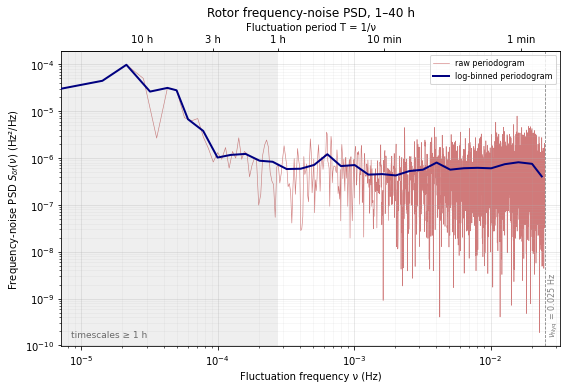

In [5]:
def log_bin(nu, S, per_decade=10):
    """Average S in log-spaced ν bins (ν > 0). Returns (ν geometric mean, mean S, n bins)."""
    edges = 10**np.arange(np.log10(nu[1]), np.log10(nu[-1]) + 1/per_decade, 1/per_decade)
    idx = np.digitize(nu[1:], edges)
    out = [(np.exp(np.log(nu[1:][idx == k]).mean()), S[1:][idx == k].mean(), (idx == k).sum())
           for k in np.unique(idx)]
    return map(np.array, zip(*out))

band = lambda nu, lo, hi: (nu >= lo) & (nu <= hi)

def inv(x):
    with np.errstate(divide='ignore'): return 1/x      # matplotlib probes x = 0 when building the axis

def period_axis(ax, per):
    top = ax.secondary_xaxis('top', functions=(inv, inv))
    top.set_xticks([p for p, _ in per]); top.set_xticklabels([l for _, l in per])
    top.xaxis.set_minor_locator(plt.NullLocator()); top.set_xlabel('Fluctuation period T = 1/ν')

T_60, R_60, F_60, SNR_60 = track_rotor(WIN_P, STEP_P, guide=(T, FR))
m60 = ((T_60 - T_REF)/3600 >= WIN_H[0]) & ((T_60 - T_REF)/3600 <= WIN_H[1])
t_p, f_p = T_60[m60], F_60[m60]
assert abs(f_p.mean() - FR[mref].mean()) < 1e-3, 'primary track is not on the same line as the base track'
dt_p = np.diff(t_p)
assert np.allclose(dt_p, dt_p[0]), 'uneven cadence'
fs_p = 1/np.median(dt_p)
f0 = f_p.mean()
delta_f = f_p - f0                                      # Hz
nu_p, S_df = periodogram(delta_f, fs=fs_p, window='hann', detrend=False)   # one segment, whole window
nu_lb, S_lb, n_lb = log_bin(nu_p, S_df)
T_rec = len(delta_f)/fs_p

print(f'mean rotor frequency f0 ({WIN_H[0]}-{WIN_H[1]} h) = {f0:.6f} Hz')
print(f'std of delta_f                        = {delta_f.std():.3e} Hz = {delta_f.std()*1e3:.4f} mHz')
print(f'tracker                               = {WIN_P:.0f} s window, {STEP_P:.0f} s step, median SNR {np.median(SNR_60[m60]):.0f}')
print(f'total duration                        = {len(delta_f)} estimates x {1/fs_p:.0f} s = {T_rec/3600:.2f} h')
print(f'Fourier resolution 1/T                = {1/T_rec:.3e} Hz')
print(f'Nyquist frequency                     = {fs_p/2:.3e} Hz  (period {2/fs_p:.0f} s)')

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(nu_p[1:], S_df[1:], color='firebrick', lw=0.6, alpha=0.6, zorder=1, label='raw periodogram')
ax.loglog(nu_lb, S_lb, color='navy', lw=2.0, zorder=3, label='log-binned periodogram')
ax.axvline(fs_p/2, color='gray', lw=0.8, ls='--')
ax.text(fs_p/2*1.04, 0.03, f'$\\nu_{{\\rm Nyq}}$ = {fs_p/2:.3f} Hz', transform=ax.get_xaxis_transform(),
        rotation=90, va='bottom', fontsize=8, color='gray')
ax.set_xlim(nu_p[1], fs_p/2*1.3)
ax.axvspan(nu_p[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.text(0.02, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('Frequency-noise PSD $S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title(f'Rotor frequency-noise PSD, {WIN_H[0]}–{WIN_H[1]} h')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)
ax.legend(fontsize=8, loc='upper right')
period_axis(ax, [(60, '1 min'), (600, '10 min'), (3600, '1 h'), (3*3600, '3 h'), (10*3600, '10 h')])
plt.tight_layout(); plt.show()

### 1.4 Window check: Hann vs rectangular

§2 compares the recoil with the measured fluctuations using a rectangular (no-taper) periodogram for
both. This checks that the measured band level barely depends on that choice. Same δf series; only the
final periodogram window changes (the tracking FFT keeps its Hann window). Individual low bins can
differ by large factors, since each is a single estimate; compare band means.

      band (Hz) |  bins | rect/Hann, band means | median bin ratio
1e-05-1.0e-04 |    13 |                  1.18 |             1.51
1e-04-1.0e-03 |   126 |                  1.08 |             1.00
1e-03-1.0e-02 |  1264 |                  0.97 |             1.00
1e-02-2.5e-02 |  2107 |                  1.02 |             1.04


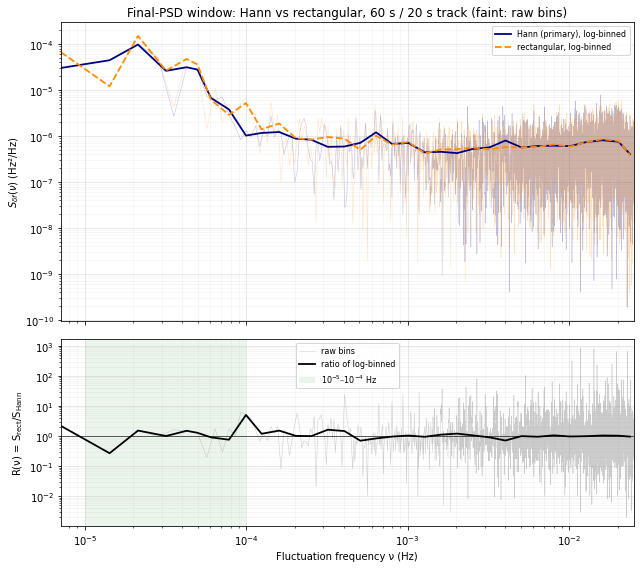

In [6]:
_, S_df_rect = periodogram(delta_f, fs=fs_p, window='boxcar', detrend=False)
_, S_lb_rect, _ = log_bin(nu_p, S_df_rect)
R_win = S_df_rect/np.where(S_df > 0, S_df, np.nan)

print(f"{'band (Hz)':>15} | {'bins':>5} | {'rect/Hann, band means':>21} | {'median bin ratio':>16}")
for lo, hi in ((1e-5, 1e-4), (1e-4, 1e-3), (1e-3, 1e-2), (1e-2, fs_p/2)):
    b = band(nu_p, lo, hi)
    print(f'{lo:.0e}-{hi:.1e} | {b.sum():5d} | {S_df_rect[b].mean()/S_df[b].mean():21.2f} | {np.median(R_win[b]):16.2f}')

fig, ax = plt.subplots(2, 1, figsize=(9, 8), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1]))
ax[0].loglog(nu_p[1:], S_df[1:], color='navy', lw=0.5, alpha=0.25)
ax[0].loglog(nu_p[1:], S_df_rect[1:], color='darkorange', lw=0.5, alpha=0.25)
ax[0].loglog(nu_lb, S_lb, color='navy', lw=1.8, label='Hann (primary), log-binned')
ax[0].loglog(nu_lb, S_lb_rect, color='darkorange', lw=1.8, ls='--', label='rectangular, log-binned')
ax[0].set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)'); ax[0].legend(fontsize=8)
ax[0].set_title(f'Final-PSD window: Hann vs rectangular, {WIN_P:.0f} s / {STEP_P:.0f} s track (faint: raw bins)')
ax[1].loglog(nu_p[1:], R_win[1:], color='gray', lw=0.5, alpha=0.4, label='raw bins')
ax[1].loglog(nu_lb, S_lb_rect/S_lb, color='k', lw=1.8, label='ratio of log-binned')
ax[1].axhline(1, color='k', lw=0.6)
ax[1].axvspan(1e-5, 1e-4, color='green', alpha=0.08, lw=0, label='10$^{-5}$–10$^{-4}$ Hz')
ax[1].set_ylabel('R(ν) = S$_{\\rm rect}$/S$_{\\rm Hann}$'); ax[1].set_xlabel('Fluctuation frequency ν (Hz)')
ax[1].legend(fontsize=8)
for a in ax: a.grid(which='major', alpha=0.35); a.grid(which='minor', alpha=0.12); a.set_xlim(nu_p[1], fs_p/2)
plt.tight_layout(); plt.show()

## 2. Expected Pb-212 recoil signal

### 2.1 Recoil signal in frequency-noise units

- Linear drag, as supported by the exponential spin-down: $I\dot\omega = -\gamma\omega$, $\gamma = I/\tau_{\rm mech}$
  (a drag coefficient, N·m·s).
- Recoil torque $\tau_0 = rF_0$; quasi-static frequency shift $\Delta f_0 = \tau_0/(2\pi\gamma)$.
- $\delta f_{\rm Pb}(t) = \Delta f_0\,e^{-\lambda t}$, $\lambda = \ln 2/T_{1/2}$, on the primary tracker's timestamps.
- **Assumption: `F0_PB` is the recoil force at t = 0, the start of the analysis window.** For any other
  origin the amplitude scales by $e^{-\lambda t_{\rm start}}$.
- **Quasi-static:** valid while τ_mech ≪ the Pb-212 mean lifetime. The exact response
  $I\dot\omega + \gamma\omega = \tau_0 e^{-\lambda t}$ adds a driven-term factor $1/(1-\lambda\tau_{\rm mech})$
  (printed below) plus a start-up transient; not included.

**Spectrum:** mean subtracted, one **rectangular** (no-taper) periodogram over the whole window, one-sided
density in Hz²/Hz, same ν grid as §1.3. The absolute level comes from Δf0; nothing is fitted to the data.
Rectangular, not Hann: a Hann window imposes its own ν⁻⁶ roll-off on this deterministic signal (§2.2).
This is a finite-record signal, not stationary noise, so its level depends on the record length.

gamma = I/tau_mech          = 2.2974e-15 N m s
tau_0 = r F0 (r = 1.38 mm)  = 7.0380e-18 N m
Delta_f0 (r = 1.38 mm)     = 4.8756e-04 Hz = 0.4876 mHz
Delta_f0 (r = 1.88 mm tip) = 6.6422e-04 Hz = 0.6642 mHz
over the window: 0.4876 -> 0.0381 mHz  (measured δf std 0.1396 mHz)


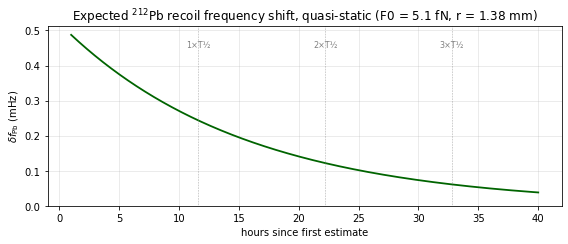

In [7]:
LAMBDA_PB = np.log(2)/(T_HALF_H*3600)             # 1/s
GAMMA_DRAG = I_TOTAL/TAU_S                        # N m s
TAU0_PB = R_EFF*F0_PB                             # N m
DF0_PB = TAU0_PB/(2*np.pi*GAMMA_DRAG)             # Hz, quasi-static
DF0_PB_TIP = R_TIP*F0_PB/(2*np.pi*GAMMA_DRAG)

t_rel = t_p - t_p[0]                              # s, t = 0 at the start of the analysis window
df_pb = DF0_PB*np.exp(-LAMBDA_PB*t_rel)           # Hz

print(f'gamma = I/tau_mech          = {GAMMA_DRAG:.4e} N m s')
print(f'tau_0 = r F0 (r = {R_EFF*1e3:.2f} mm)  = {TAU0_PB:.4e} N m')
print(f'Delta_f0 (r = {R_EFF*1e3:.2f} mm)     = {DF0_PB:.4e} Hz = {DF0_PB*1e3:.4f} mHz')
print(f'Delta_f0 (r = {R_TIP*1e3:.2f} mm tip) = {DF0_PB_TIP:.4e} Hz = {DF0_PB_TIP*1e3:.4f} mHz')
print(f'over the window: {df_pb[0]*1e3:.4f} -> {df_pb[-1]*1e3:.4f} mHz  (measured δf std {delta_f.std()*1e3:.4f} mHz)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot((t_p - T_REF)/3600, df_pb*1e3, color='darkgreen', lw=1.8)
for n in range(1, int(t_rel[-1]/3600/T_HALF_H) + 1):
    h = (t_p[0] - T_REF)/3600 + n*T_HALF_H
    ax.axvline(h, color='gray', lw=0.6, ls=':'); ax.text(h, DF0_PB*1e3*0.97, f'{n}×T½', fontsize=8, color='gray', ha='center', va='top')
ax.set_xlabel('hours since first estimate'); ax.set_ylabel('$\\delta f_{\\rm Pb}$ (mHz)')
ax.set_title(f'Expected $^{{212}}$Pb recoil frequency shift, quasi-static (F0 = {F0_PB*1e15:.1f} fN, r = {R_EFF*1e3:.2f} mm)')
ax.set_ylim(0, DF0_PB*1e3*1.05); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

In [8]:
# rectangular spectral density of the expected signal, absolute, + Parseval and slope checks
x_pb = df_pb - df_pb.mean()
nu_pr, S_pb_rect = periodogram(x_pb, fs=fs_p, window='boxcar', detrend=False)    # Hz²/Hz, one-sided
assert np.allclose(nu_pr, nu_p)
S_pb_rect_tip = S_pb_rect*(R_TIP/R_EFF)**2
dnu = nu_p[1] - nu_p[0]                                   # = 1/T

ms_total, ms_dc, ms_ac = np.mean(df_pb**2), df_pb.mean()**2, np.mean(x_pb**2)
integral = S_pb_rect.sum()*dnu                            # Σ S Δν over all one-sided bins (DC, Nyquist not doubled)
print('PARSEVAL (rectangular, one-sided density)')
print(f'  mean square of δf_Pb          = {ms_total:.6e} Hz²')
print(f'  - mean² (removed, DC)         = {ms_dc:.6e} Hz²')
print(f'  = mean square after mean sub. = {ms_ac:.6e} Hz²')
print(f'  Σ S Δν over all bins          = {integral:.6e} Hz²')
print(f'  fractional difference         = {(integral - ms_ac)/ms_ac:+.2e}')
print(f'  power in the lowest nonzero bin: {S_pb_rect[1]*dnu/ms_ac:.1%}, lowest 3: {S_pb_rect[1:4].sum()*dnu/ms_ac:.1%}')
for lo, hi in ((1e-4, 1e-3), (1e-3, 5e-3)):
    m = band(nu_p, lo, hi)
    print(f'  log-log slope {lo:.0e}-{hi:.0e} Hz: {np.polyfit(np.log10(nu_p[m]), np.log10(S_pb_rect[m]), 1)[0]:.2f}')

PARSEVAL (rectangular, one-sided density)
  mean square of δf_Pb          = 4.633944e-08 Hz²
  - mean² (removed, DC)         = 3.107814e-08 Hz²
  = mean square after mean sub. = 1.526130e-08 Hz²
  Σ S Δν over all bins          = 1.526130e-08 Hz²
  fractional difference         = -4.34e-16
  power in the lowest nonzero bin: 57.6%, lowest 3: 81.0%
  log-log slope 1e-04-1e-03 Hz: -2.00
  log-log slope 1e-03-5e-03 Hz: -1.98


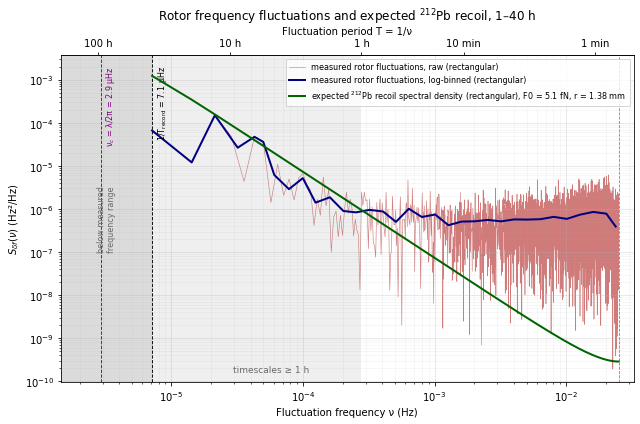

In [9]:
# overlay: measured fluctuations and expected recoil, both rectangular full-record periodograms
nu_c_pb = LAMBDA_PB/(2*np.pi)
def nyq_display(S):
    # display only: periodogram leaves the Nyquist bin undoubled; x2 there gives the one-sided density
    S = S.copy(); S[-1] *= 2; return S
S_meas_ov, S_pb_ov = nyq_display(S_df_rect), nyq_display(S_pb_rect)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(nu_p[1:], S_meas_ov[1:], color='firebrick', lw=0.6, alpha=0.6, zorder=1,
          label='measured rotor fluctuations, raw (rectangular)')
ax.loglog(nu_lb, S_lb_rect, color='navy', lw=2.0, zorder=3, label='measured rotor fluctuations, log-binned (rectangular)')
ax.loglog(nu_p[1:], S_pb_ov[1:], color='darkgreen', lw=2.0, zorder=4,
          label=f'expected $^{{212}}$Pb recoil spectral density (rectangular), '
                f'F0 = {F0_PB*1e15:.1f} fN, r = {R_EFF*1e3:.2f} mm')
ax.set_ylim(S_meas_ov[1:].min()*0.5, max(S_meas_ov[1:].max(), S_pb_ov[1:].max())*3)
x_left = min(nu_c_pb, nu_p[1])*0.5
ax.set_xlim(x_left, fs_p/2*1.3)
ax.axvline(fs_p/2, color='gray', lw=0.8, ls='--')
ax.axvspan(nu_p[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.axvspan(x_left, nu_p[1], color='gray', alpha=0.28, lw=0)
ax.text(np.sqrt(x_left*nu_p[1]), 0.5, 'below measured\nfrequency range', transform=ax.get_xaxis_transform(),
        rotation=90, ha='center', va='center', fontsize=8, color='dimgray')
for x, lab, col in ((nu_p[1], f'1/T$_{{\\rm record}}$ = {nu_p[1]*1e6:.1f} µHz', 'k'),
                    (nu_c_pb, f'ν$_c$ = λ/2π = {nu_c_pb*1e6:.1f} µHz', 'purple')):
    ax.axvline(x, color=col, lw=0.9, ls='--')
    ax.text(x*1.07, 0.97, lab, transform=ax.get_xaxis_transform(), rotation=90, va='top', fontsize=8, color=col)
ax.text(0.30, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('$S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title(f'Rotor frequency fluctuations and expected $^{{212}}$Pb recoil, {WIN_H[0]}–{WIN_H[1]} h')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)
ax.legend(fontsize=8, loc='upper right')
period_axis(ax, [(60, '1 min'), (600, '10 min'), (3600, '1 h'), (10*3600, '10 h'), (100*3600, '100 h')])
plt.tight_layout(); plt.show()

In [10]:
print(f'SUMMARY (quasi-static, t = 0 at the start of {WIN_H[0]}-{WIN_H[1]} h)')
print(f'  gamma          = {GAMMA_DRAG:.4e} N m s')
print(f'  tau_mech       = {TAU_S/60:.1f} min = {TAU_S/3600:.3f} h')
print(f'  I              = {I_TOTAL:.2e} kg m^2')
print(f'  F0             = {F0_PB:.2e} N')
print(f'  r              = {R_EFF:.2e} m   (tip {R_TIP:.2e} m)')
print(f'  tau_recoil_0   = {TAU0_PB:.4e} N m   (tip {R_TIP*F0_PB:.4e})')
print(f'  Delta_f0       = {DF0_PB:.4e} Hz = {DF0_PB*1e3:.4f} mHz   (tip {DF0_PB_TIP*1e3:.4f} mHz)')
print(f'  lambda         = {LAMBDA_PB:.4e} 1/s   (mean lifetime {1/LAMBDA_PB/3600:.2f} h), half-life {T_HALF_H:.1f} h')
print(f'  nu_c = λ/2π    = {nu_c_pb:.3e} Hz;  1/T_record = {nu_p[1]:.3e} Hz')
print(f'  exact-response driven-term factor 1/(1 - λ τ_mech) = {1/(1 - LAMBDA_PB*TAU_S):.3f} (not applied)')
print('\nexpected recoil vs measured fluctuations, both rectangular, raw bins:')
print(f"{'ν (µHz)':>8} | {'recoil':>9} | {'(tip)':>9} | {'measured':>9} | {'ratio':>6}")
for j in range(1, 7):
    print(f'{nu_p[j]*1e6:8.1f} | {S_pb_rect[j]:9.2e} | {S_pb_rect_tip[j]:9.2e} | {S_df_rect[j]:9.2e} | {S_pb_rect[j]/S_df_rect[j]:6.2f}')
for lo, hi in ((1e-5, 1e-4), (1e-4, 1e-3), (1e-3, 1e-2)):
    bh = band(nu_p, lo, hi)
    print(f'band {lo:.0e}-{hi:.0e} Hz: recoil/measured, ratio of band means {S_pb_rect[bh].mean()/S_df_rect[bh].mean():.3f}')

SUMMARY (quasi-static, t = 0 at the start of 1-40 h)
  gamma          = 2.2974e-15 N m s
  tau_mech       = 79.8 min = 1.330 h
  I              = 1.10e-11 kg m^2
  F0             = 5.10e-15 N
  r              = 1.38e-03 m   (tip 1.88e-03 m)
  tau_recoil_0   = 7.0380e-18 N m   (tip 9.5880e-18)
  Delta_f0       = 4.8756e-04 Hz = 0.4876 mHz   (tip 0.6642 mHz)
  lambda         = 1.8164e-05 1/s   (mean lifetime 15.29 h), half-life 10.6 h
  nu_c = λ/2π    = 2.891e-06 Hz;  1/T_record = 7.123e-06 Hz
  exact-response driven-term factor 1/(1 - λ τ_mech) = 1.095 (not applied)

expected recoil vs measured fluctuations, both rectangular, raw bins:
 ν (µHz) |    recoil |     (tip) |  measured |  ratio
     7.1 |  1.23e-03 |  2.29e-03 |  6.64e-05 |  18.58
    14.2 |  3.45e-04 |  6.41e-04 |  1.21e-05 |  28.60
    21.4 |  1.57e-04 |  2.91e-04 |  1.50e-04 |   1.04
    28.5 |  8.89e-05 |  1.65e-04 |  4.87e-05 |   1.83
    35.6 |  5.71e-05 |  1.06e-04 |  4.35e-06 |  13.15
    42.7 |  3.98e-05 |  7.38e-05 

**Reading the comparison.**
- The recoil is essentially a slow drift: most of its power sits in the lowest few bins (printed above).
- Each raw bin is a single estimate (χ², 2 dof), so a ratio in one low bin is uncertain by a large factor;
  band means are steadier.
- The recoil's ν⁻² tail above the lowest bins comes from the record's end-to-end jump (§2.2), not from
  structure in the decay, so where the curves cross is not a statement about detectability at those ν.
- A time-domain fit of $e^{-\lambda t}$ to δf(t) is the natural detection statistic for this known
  template; not done here.

### 2.2 Window diagnostic (validation)

Spectral shape of the same δf_Pb(t): analytic infinite-duration exponential ∝ 1/[λ² + (2πν)²],
rectangular finite record, Hann finite record, all normalised at ν = 1/T. Expected slopes: −2, −2, and
−6 (Hann sidelobe roll-off). The ν⁻² of the analytic curve comes from the step at its onset, and that
of the rectangular record from the jump between its first and last values.

                         | slope 1e-04-1e-03 Hz | slope 1e-03-5e-03 Hz
analytic (infinite)      |                  -2.00 |                  -2.00
rectangular, finite      |                  -2.00 |                  -1.98
Hann, finite             |                  -6.00 |                  -6.00


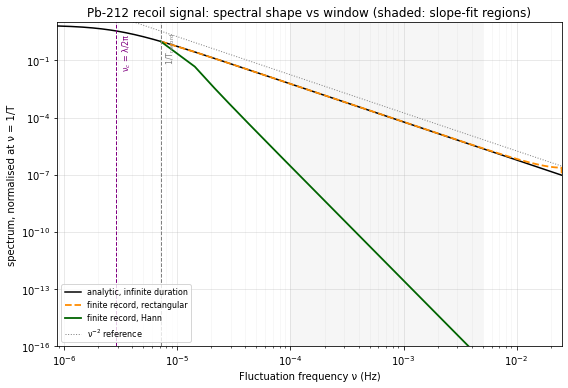

In [11]:
_, S_pb_hann = periodogram(df_pb - df_pb.mean(), fs=fs_p, window='hann', detrend=False)
S_ana = lambda nu: 1/(LAMBDA_PB**2 + (2*np.pi*nu)**2)
j0 = 1                                                   # normalisation bin, ν = 1/T
curves = {'analytic (infinite)': S_ana(nu_p)/S_ana(nu_p[j0]),
          'rectangular, finite': S_pb_rect/S_pb_rect[j0],
          'Hann, finite': S_pb_hann/S_pb_hann[j0]}

def slope(nu, S, lo, hi):
    m = band(nu, lo, hi)
    return np.polyfit(np.log10(nu[m]), np.log10(S[m]), 1)[0]

REGIONS = [(1e-4, 1e-3), (1e-3, 5e-3)]                  # well above ν_c and 1/T, well below Nyquist
print(f"{'':24s} | " + ' | '.join(f'slope {lo:.0e}-{hi:.0e} Hz' for lo, hi in REGIONS))
for name, S in curves.items():
    print(f'{name:24s} | ' + ' | '.join(f'{slope(nu_p, S, lo, hi):22.2f}' for lo, hi in REGIONS))

fig, ax = plt.subplots(figsize=(8, 5.5))
nu_fine = np.logspace(np.log10(min(nu_c_pb, nu_p[1])*0.3), np.log10(fs_p/2), 400)
ax.loglog(nu_fine, S_ana(nu_fine)/S_ana(nu_p[j0]), color='k', lw=1.5, label='analytic, infinite duration')
ax.loglog(nu_p[1:], curves['rectangular, finite'][1:], color='darkorange', lw=1.8, ls='--', label='finite record, rectangular')
ax.loglog(nu_p[1:], curves['Hann, finite'][1:], color='darkgreen', lw=1.8, label='finite record, Hann')
ref = (nu_fine/1e-4)**-2 * (S_ana(1e-4)/S_ana(nu_p[j0]))*3
ax.loglog(nu_fine, ref, color='gray', lw=1, ls=':', label='ν$^{-2}$ reference')
for x, lab, col in ((nu_c_pb, 'ν$_c$ = λ/2π', 'purple'), (nu_p[1], '1/T$_{\\rm record}$', 'gray')):
    ax.axvline(x, color=col, lw=1, ls='--')
    ax.text(x*1.08, 0.97, lab, rotation=90, va='top', fontsize=8, color=col, transform=ax.get_xaxis_transform())
for lo, hi in REGIONS: ax.axvspan(lo, hi, color='gray', alpha=0.07, lw=0)
ax.set_ylim(1e-16, 10); ax.set_xlim(nu_fine[0], fs_p/2)
ax.set_xlabel('Fluctuation frequency ν (Hz)'); ax.set_ylabel('spectrum, normalised at ν = 1/T')
ax.set_title('Pb-212 recoil signal: spectral shape vs window (shaded: slope-fit regions)')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()